In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

In [2]:
df = pd.read_csv('OrderDetails_2026_03_15-2026_06_15.csv')
df.info()
df.head(10)
df.dropna()
df = df[df['Amount'] > 0]

<class 'pandas.DataFrame'>
RangeIndex: 3254 entries, 0 to 3253
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Opened           3254 non-null   str    
 1   # of Guests      3254 non-null   int64  
 2   Table            3084 non-null   str    
 3   Discount Amount  3254 non-null   float64
 4   Amount           3254 non-null   float64
 5   Tax              3254 non-null   float64
 6   Tip              3254 non-null   float64
 7   Gratuity         3254 non-null   float64
 8   Closed           3238 non-null   str    
dtypes: float64(5), int64(1), str(3)
memory usage: 228.9 KB


In [3]:
df['Amount'].sort_values(ascending=False)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [4]:
opened_dt = pd.to_datetime(df['Opened'], format='%m/%d/%y %I:%M %p')
closed_dt = pd.to_datetime(df['Closed'], format='%m/%d/%y %I:%M %p')

df.insert(0, 'Date', opened_dt.dt.strftime('%m/%d/%y'))
df['Duration'] = (closed_dt - opened_dt).dt.total_seconds() / 60  # minutes
df['Duration'].info()
df = df[df['Duration'] >= 15]

df['Opened'] = opened_dt.dt.strftime('%I:%M %p')
df['Closed'] = closed_dt.dt.strftime('%I:%M %p')

df.head(10)

<class 'pandas.Series'>
Index: 3088 entries, 0 to 3252
Series name: Duration
Non-Null Count  Dtype  
--------------  -----  
3088 non-null   float64
dtypes: float64(1)
memory usage: 48.2 KB


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [5]:
# df['Table'].split()

# Value per Person per 15 Minutes

In [6]:
df['VPCPM'] = (df['Amount'] / df['# of Guests']) / (df['Duration'] / 15)
df['VPCPM'].head(10)
df['Mean VPCPM'] = df['# of Guests'].map(df.groupby('# of Guests')['VPCPM'].mean()) # understand why this works
df.head(20).sort_values(by = 'VPCPM', ascending = False)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [7]:
# df.groupby('# of Guests')['VPCPM'].agg(['mean', 'count', 'min', 'max'])
# # df[df['# of Guests'] == 1][['Amount', 'Duration', 'VPCPM']]
df.groupby('# of Guests')['VPCPM'].mean().reset_index().rename(columns={'VPCPM': 'Mean VPCPM'})

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


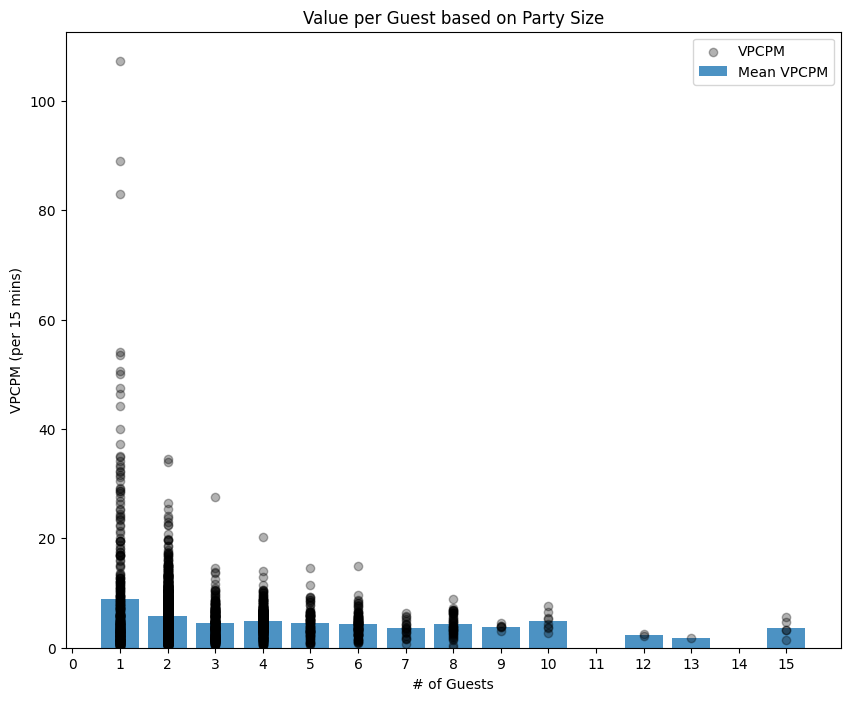

In [8]:
import matplotlib.pyplot as plt

mean_vpcpm = df.groupby('# of Guests')['VPCPM'].mean()
fig, ax = plt.subplots(figsize = (10,8))

ax.bar(mean_vpcpm.index, mean_vpcpm, alpha = 0.8)
ax.scatter(df['# of Guests'], df['VPCPM'], alpha=0.3, color='black')

plt.title('Value per Guest based on Party Size')
plt.xlabel('# of Guests')
plt.ylabel('VPCPM (per 15 mins)')
plt.legend(['VPCPM', 'Mean VPCPM'],loc = 'best')
plt.xticks(range(0,16)); # semi-colon prevents text output 

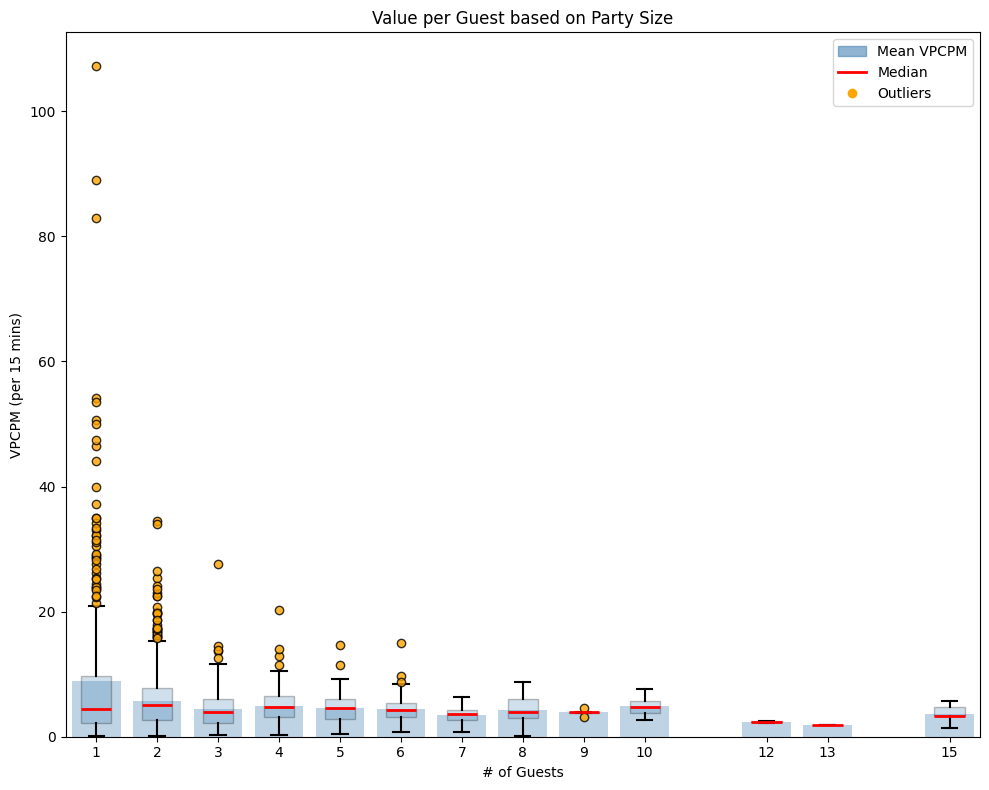

In [9]:
import matplotlib.pyplot as plt

mean_vpcpm = df.groupby('# of Guests')['VPCPM'].mean()
guest_sizes = sorted(df['# of Guests'].unique())
groups = [df[df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(mean_vpcpm.index, mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)

ax.boxplot(groups, positions=guest_sizes, widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.25),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5),
           zorder=2)

ax.set_xticks(guest_sizes)
ax.set_xlabel('# of Guests')
ax.set_ylabel('VPCPM (per 15 mins)')
ax.set_title('Value per Guest based on Party Size')

handles = [
    plt.Rectangle((0, 0), 1, 1, color='steelblue', alpha=0.6),
    plt.Line2D([0], [0], color='red', linewidth=2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8),
]
ax.legend(handles, ['Mean VPCPM', 'Median', 'Outliers'], loc='best')
plt.tight_layout()
plt.show()

## Who Spends More Per Hour? — Descriptive Analysis by Party Size

## Seating Sections & Capacity

Splitting `Table` into its section (Bar, Black Duck, Evangeline, Open Lounge) and attaching each table's seat capacity range, so value-per-party-size can be compared *within* a section instead of pooled across very different seating types (a 1-seat bar stool behaves nothing like a 5-top).

All capacities below are confirmed (no more mode-based inference): `E1`/`E2` are fixed 2-seaters, `E3` flexes 5-6; Black Duck currently only operates `BD1` (2), `BD2` (2-3), `BD3` (3-4) (`BD5` is retired). Ranges are stored as `Capacity_Min`/`Capacity_Max` rather than a single number.

The Lounge also has confirmed combined-table capacities (`O1`+`O2`, `O4`+`O5`, `O7`+`O8`, `O9`+`O10`) for when parties are seated across two adjacent tables, but the raw `Table` field never records a combined code (each row is a single table like `O1`) — see README for the numbers; they aren't modeled in `Capacity_Min`/`Capacity_Max` below since there's no signal in the data to detect when two tables were actually combined for one party.


In [10]:
def get_section(table):
    if pd.isna(table):
        return 'Unknown/To-Go'
    if table.startswith('BD'):
        return 'Black Duck'
    if table.startswith('B'):
        return 'Bar'
    if table.startswith('E'):
        return 'Evangeline'
    if table.startswith('O'):
        return 'Open Lounge'
    return 'Unknown'

df['Section'] = df['Table'].map(get_section)

# Confirmed (min, max) seat range per table. BD5 and B13/B14 are intentionally excluded —
# BD5 is retired, B13/B14 are standing-wait placeholders, not real seats.
TABLE_CAPACITY_RANGE = {}
TABLE_CAPACITY_RANGE.update({f'B{i}': (1, 1) for i in range(1, 13)})
TABLE_CAPACITY_RANGE.update({f'O{i}': (3, 3) if i in (1, 8, 10) else (2, 2) for i in range(1, 11)})
TABLE_CAPACITY_RANGE.update({'E1': (2, 2), 'E2': (2, 2), 'E3': (5, 6)})
TABLE_CAPACITY_RANGE.update({'BD1': (2, 2), 'BD2': (2, 3), 'BD3': (3, 4)})

df['Capacity_Min'] = df['Table'].map(lambda t: TABLE_CAPACITY_RANGE.get(t, (None, None))[0])
df['Capacity_Max'] = df['Table'].map(lambda t: TABLE_CAPACITY_RANGE.get(t, (None, None))[1])

df[['Table', 'Section', 'Capacity_Min', 'Capacity_Max']].drop_duplicates().sort_values(['Section', 'Table'])

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [11]:
unassigned = df[df['Capacity_Max'].isna() & df['Table'].notna()]
print('Tables with no capacity assigned (excluded from capacity-based analysis):')
print(unassigned['Table'].value_counts())

overbooked = df[df['# of Guests'] > df['Capacity_Max']]
print(f'\nRows exceeding assigned max capacity ({len(overbooked)}) - sanity-check for the confirmed capacities:')
overbooked[['Table', 'Section', 'Capacity_Min', 'Capacity_Max', '# of Guests', 'Amount']]

Tables with no capacity assigned (excluded from capacity-based analysis):
Table
BD5    60
B14    14
B13     7
Name: count, dtype: int64

Rows exceeding assigned max capacity (1441) - sanity-check for the confirmed capacities:


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Bar vs. Table Seating

The bar (12 single-guest stools) and the table sections (Black Duck, Evangeline, Open Lounge) serve very different party-size ranges, so VPCPM is plotted separately for each rather than pooled.

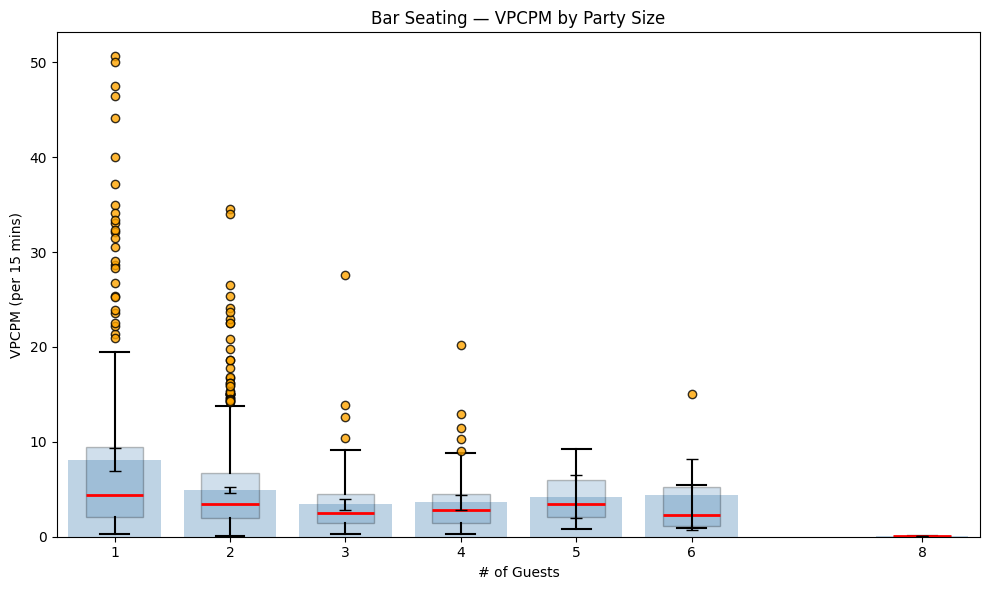

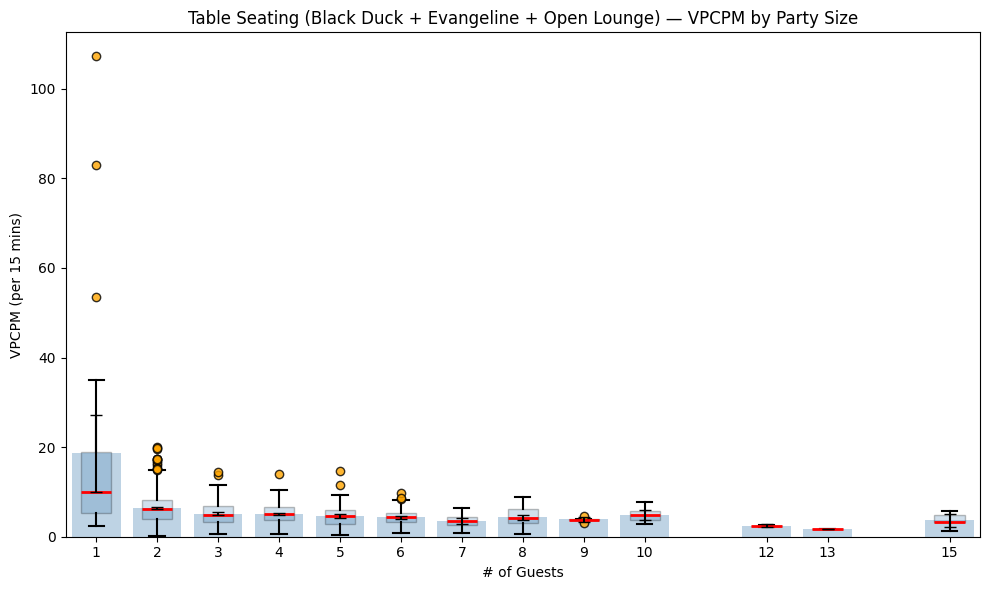

In [12]:
def plot_vpcpm_by_party_size(sub_df, title):
    grouped = sub_df.groupby('# of Guests')['VPCPM']
    mean_vpcpm = grouped.mean()
    sem_vpcpm = grouped.sem().fillna(0)
    guest_sizes = sorted(sub_df['# of Guests'].unique())
    groups = [sub_df[sub_df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(mean_vpcpm.index, mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)
    ax.errorbar(mean_vpcpm.index, mean_vpcpm, yerr=1.96 * sem_vpcpm,
                fmt='none', ecolor='black', elinewidth=1.5, capsize=4, zorder=3)
    ax.boxplot(groups, positions=guest_sizes, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.25),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               zorder=2)
    ax.set_xticks(guest_sizes)
    ax.set_xlabel('# of Guests')
    ax.set_ylabel('VPCPM (per 15 mins)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

bar_df = df[df['Section'] == 'Bar']
table_df = df[df['Section'].isin(['Black Duck', 'Evangeline', 'Open Lounge'])]

plot_vpcpm_by_party_size(bar_df, 'Bar Seating — VPCPM by Party Size')
plot_vpcpm_by_party_size(table_df, 'Table Seating (Black Duck + Evangeline + Open Lounge) — VPCPM by Party Size')

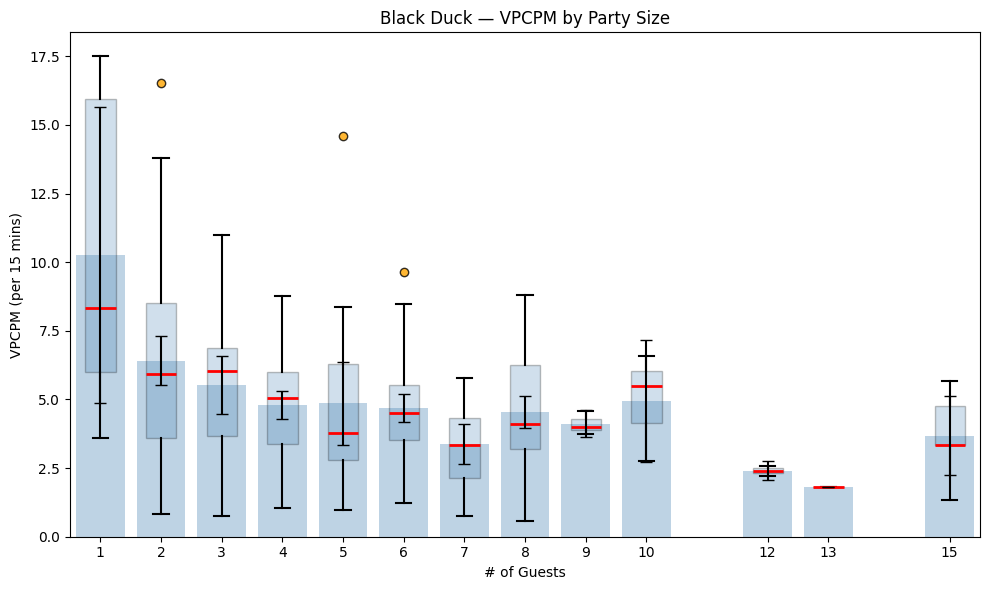

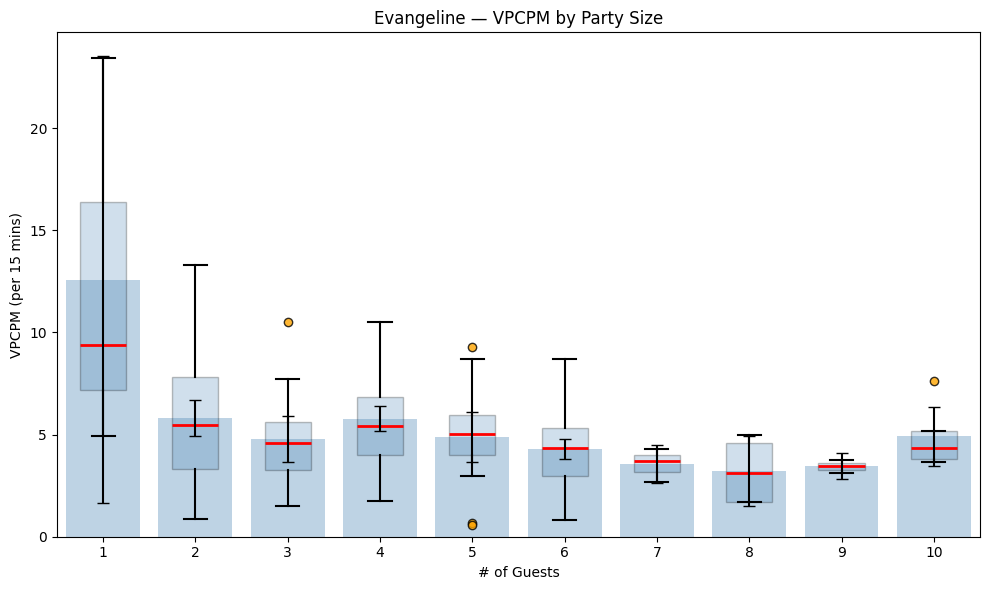

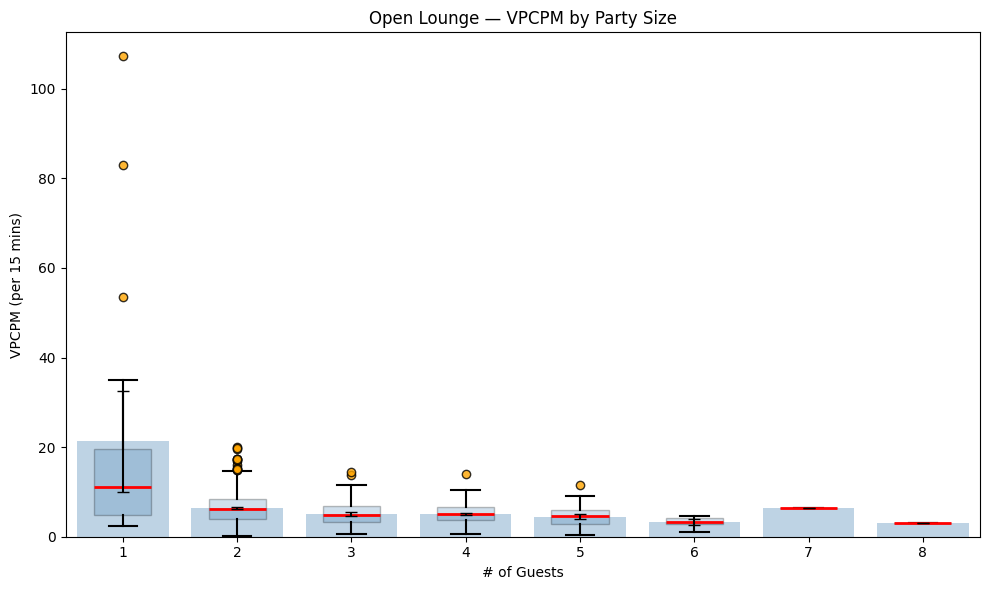

In [13]:
for section in ['Black Duck', 'Evangeline', 'Open Lounge']:
    plot_vpcpm_by_party_size(df[df['Section'] == section], f'{section} — VPCPM by Party Size')

## Table-Level Revenue Rate (TPCPM)

VPCPM normalizes by guest count, which is useful for per-seat comparisons but can obscure how much a table earns in total. **TPCPM** (Total revenue Per table, Per 15 Minutes) = `Amount / (Duration / 15)` answers the capacity-planning question directly: for a table of a given size, does a full party or a smaller one generate more $/15min?

In [14]:
df['TPCPM'] = df['Amount'] / (df['Duration'] / 15)

df.groupby(['Section', '# of Guests'])['TPCPM'].agg(['mean', 'count']).round(2)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Section Summary & Recommendations

Ranking party sizes within each section by a **shrinkage-weighted VPCPM** score — low-order-count party sizes get pulled toward their section's overall mean (weight = that section's median order count), so a party size backed by only a couple of orders can't outrank one backed by dozens purely on noise. Raw mean, its 95% CI, and TPCPM are shown alongside for transparency.

In [15]:
summary = (
    df.groupby(['Section', '# of Guests'])
      .agg(**{
          'Mean VPCPM': ('VPCPM', 'mean'),
          'SEM VPCPM': ('VPCPM', 'sem'),
          'Mean TPCPM': ('TPCPM', 'mean'),
          'SEM TPCPM': ('TPCPM', 'sem'),
          'Orders': ('VPCPM', 'count'),
      })
      .reset_index()
)
summary['95% CI VPCPM'] = 1.96 * summary['SEM VPCPM'].fillna(0)
summary['95% CI TPCPM'] = 1.96 * summary['SEM TPCPM'].fillna(0)

# Shrinkage-weighted score: pulls low-order party sizes toward their section's overall
# mean (k = that section's median order count), so a handful of orders can't outrank
# a party size backed by dozens of them.
section_means = df.groupby('Section')[['VPCPM', 'TPCPM']].mean()
summary['Section Mean VPCPM'] = summary['Section'].map(section_means['VPCPM'])
summary['Section Mean TPCPM'] = summary['Section'].map(section_means['TPCPM'])
k = summary.groupby('Section')['Orders'].transform('median')
n = summary['Orders']
summary['Weighted VPCPM'] = (n / (n + k)) * summary['Mean VPCPM'] + (k / (n + k)) * summary['Section Mean VPCPM']
summary['Weighted TPCPM'] = (n / (n + k)) * summary['Mean TPCPM'] + (k / (n + k)) * summary['Section Mean TPCPM']

display_cols = ['Section', '# of Guests', 'Mean VPCPM', '95% CI VPCPM', 'Weighted VPCPM', 'Mean TPCPM', 'Weighted TPCPM', 'Orders']
(
    summary[display_cols]
        .sort_values(['Section', 'Weighted VPCPM'], ascending=[True, False])
        .round(2)
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)
